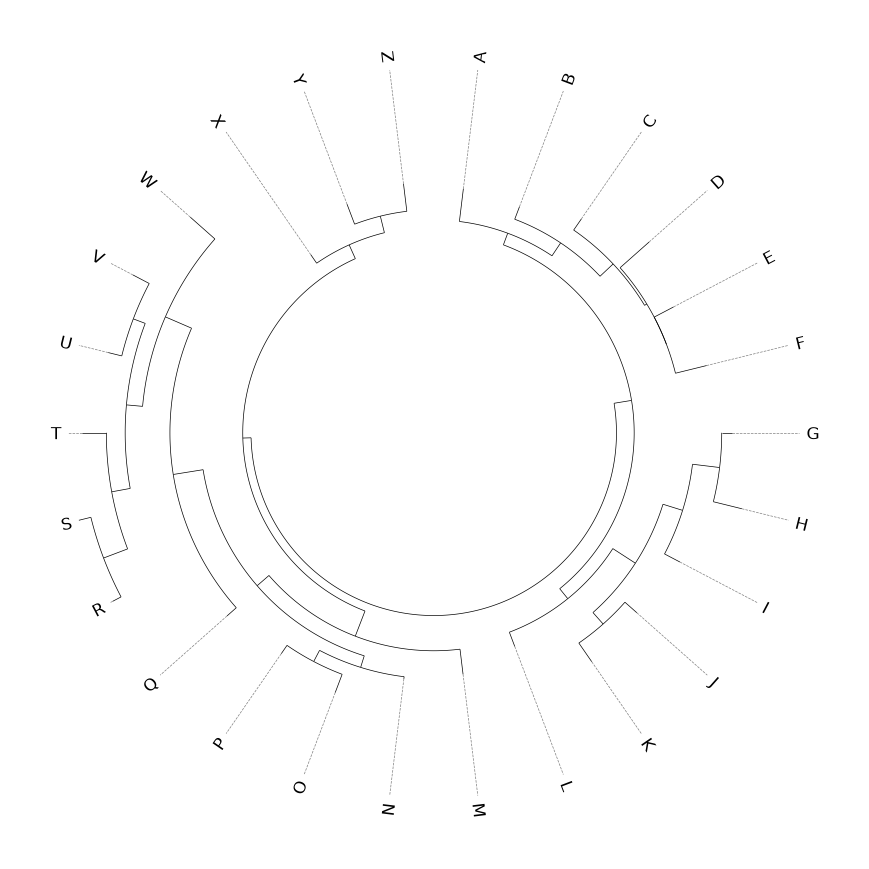

In [1]:
from pycirclize import Circos
from pycirclize.utils import load_example_tree_file

tree_file = load_example_tree_file("alphabet.nwk")
circos, tv = Circos.initialize_from_tree(tree_file)
fig = circos.plotfig()

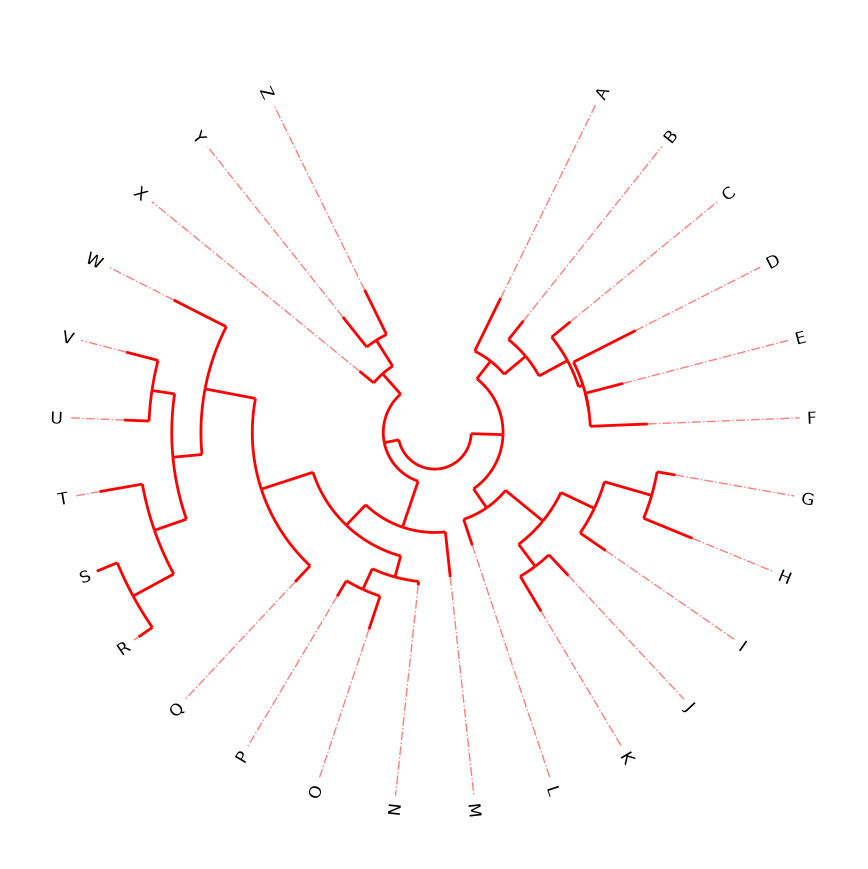

In [2]:
from pycirclize import Circos
from pycirclize.utils import load_example_tree_file

tree_file = load_example_tree_file("alphabet.nwk")
circos, tv = Circos.initialize_from_tree(
    tree_file,
    start=20,                                # Default: 0
    end=340,                                 # Default: 360
    r_lim=(10, 100),                         # Default: (50, 100)
    line_kws=dict(color="red", lw=2),        # Default: {}, Change color & linewidth
    align_line_kws=dict(ls="dashdot", lw=1), # Default: {}, Change linestyle & linewidth
)
fig = circos.plotfig()

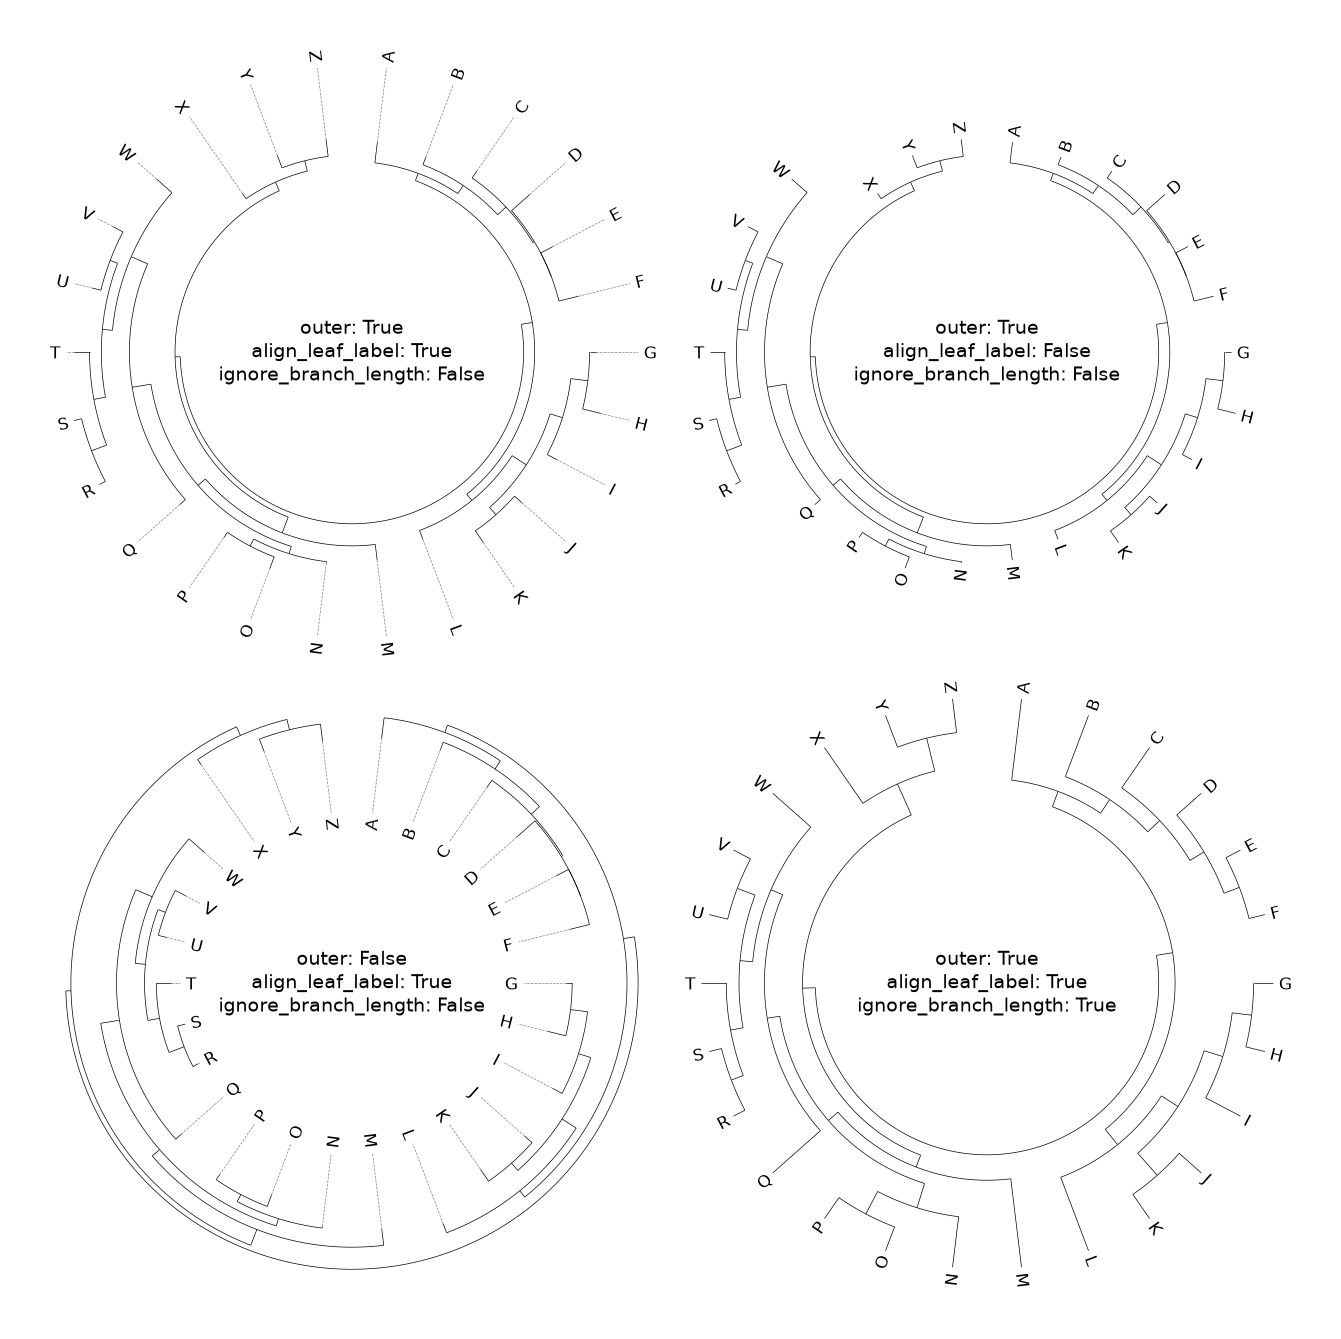

In [3]:
from pycirclize import Circos
from pycirclize.utils import load_example_tree_file
import matplotlib.pyplot as plt

# Create 2x2 polar subplots
fig = plt.figure(figsize=(16, 16))
fig.subplots_adjust(wspace=0.05, hspace=0.05)
ax_list = fig.subplots(2, 2, subplot_kw=dict(polar=True)).flatten()

# Define 4 types kwargs for `Circos.initialize_from_tree()` method
kwargs_list = [
    dict(outer=True, align_leaf_label=True, ignore_branch_length=False),
    dict(outer=True, align_leaf_label=False, ignore_branch_length=False),
    dict(outer=False, align_leaf_label=True, ignore_branch_length=False),
    dict(outer=True, align_leaf_label=True, ignore_branch_length=True),
]

# Plot trees with different kwargs
tree_file = load_example_tree_file("alphabet.nwk")
for ax, kwargs in zip(ax_list, kwargs_list):
    circos, tv = Circos.initialize_from_tree(tree_file, r_lim=(60, 100), **kwargs)
    kwargs_text = "\n".join([f"{k}: {v}" for k, v in kwargs.items()])
    circos.text(kwargs_text, size=14)
    circos.plotfig(ax=ax)

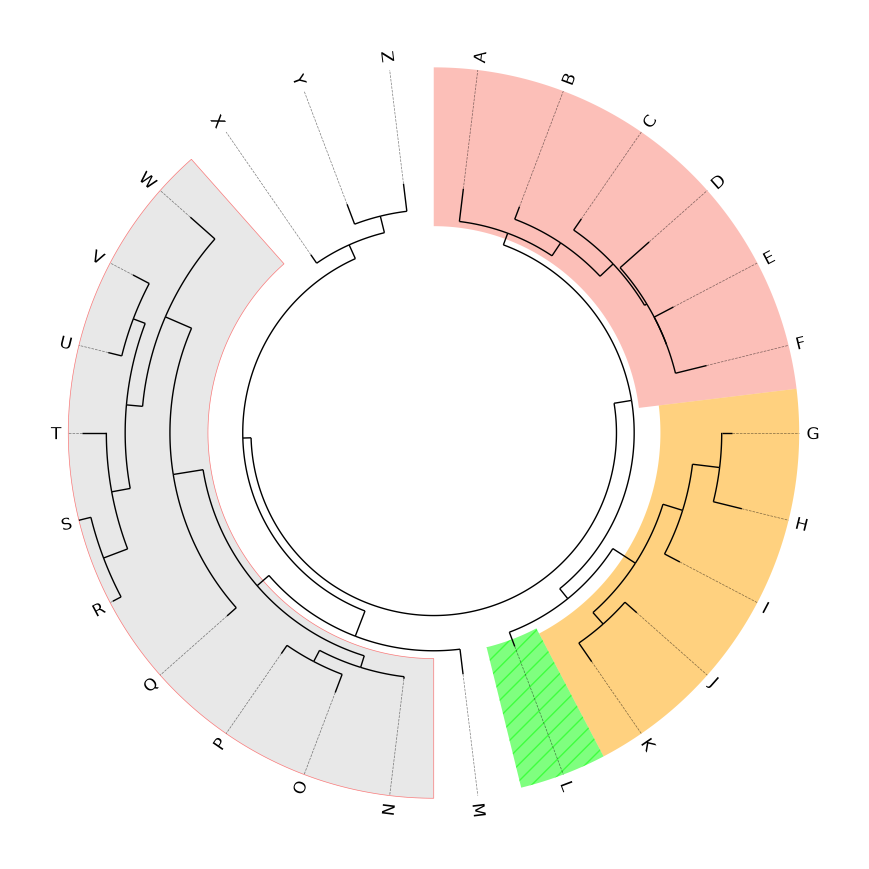

In [4]:
from pycirclize import Circos
from pycirclize.utils import load_example_tree_file

tree_file = load_example_tree_file("alphabet.nwk")
circos, tv = Circos.initialize_from_tree(tree_file, line_kws=dict(lw=1))

# Plot highlight on [A,B,C,D,E,F] MRCA(Most Recent Common Ancestor) node
tv.highlight(["A", "B", "C", "D", "E", "F"], color="salmon")
# Plot highlight on [G,K] MRCA node
tv.highlight(["G", "K"], color="orange")
# Plot highlight on L node with '//' hatch pattern
tv.highlight("L", color="lime", hatch="//", ec="white")
# Plot highlight on [N,W] MRCA node with edge line
tv.highlight(["N", "W"], color="lightgrey", alpha=0.5, ec="red", lw=0.5)

fig = circos.plotfig()